Total alligator crack frames found: 15
Frames with ground truth masks: 15

Testing on first frame...


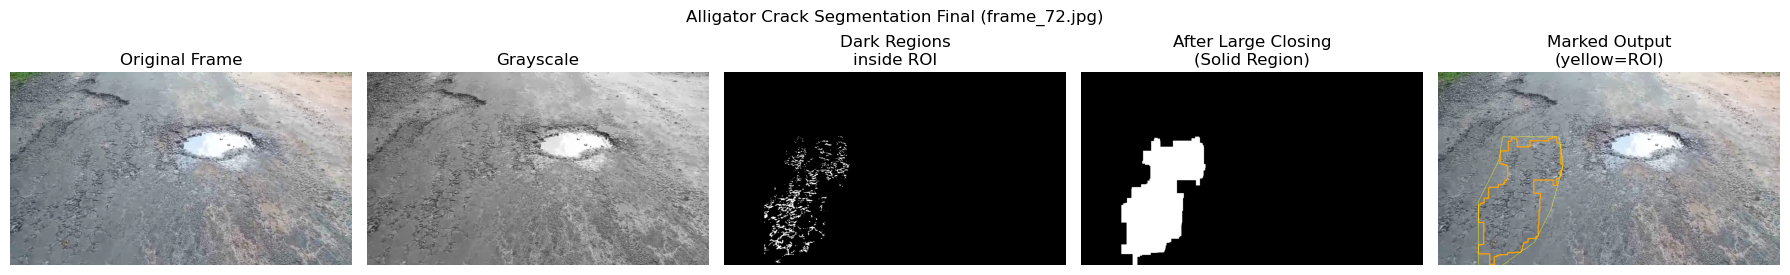

Test done. Check: Member3_Segmentation/test_steps_frame_72.jpg
Solid regions found: 1

If region not solid enough: increase CLOSING_KERNEL_SIZE (try 41 or 51)
If region too large: decrease CLOSING_KERNEL_SIZE (try 21)
If too much noise: decrease THRESHOLD_VALUE (try 90 or 80)

Processing all alligator crack frames...
Done. All outputs saved in: Member3_Segmentation/

--- Evaluation Metrics (Frames with Ground Truth) ---
Frame                  Accuracy  Precision  Recall    F1        IoU       Dice
------------------------------------------------------------------------------------------
frame_72.jpg 	 0.8889 	 0.7864 	 0.439 	 0.5635 	 0.3922 	 0.5635
frame_73.jpg 	 0.8757 	 0.7132 	 0.4033 	 0.5153 	 0.347 	 0.5153
frame_74.jpg 	 0.8605 	 0.6043 	 0.3812 	 0.4675 	 0.305 	 0.4675
frame_75.jpg 	 0.8474 	 0.5311 	 0.3505 	 0.4223 	 0.2677 	 0.4223
frame_76.jpg 	 0.8422 	 0.4998 	 0.3453 	 0.4084 	 0.2566 	 0.4084
frame_77.jpg 	 0.831 	 0.4399 	 0.2965 	 0.3542 	 0.2152 	 0.3542
frame_78

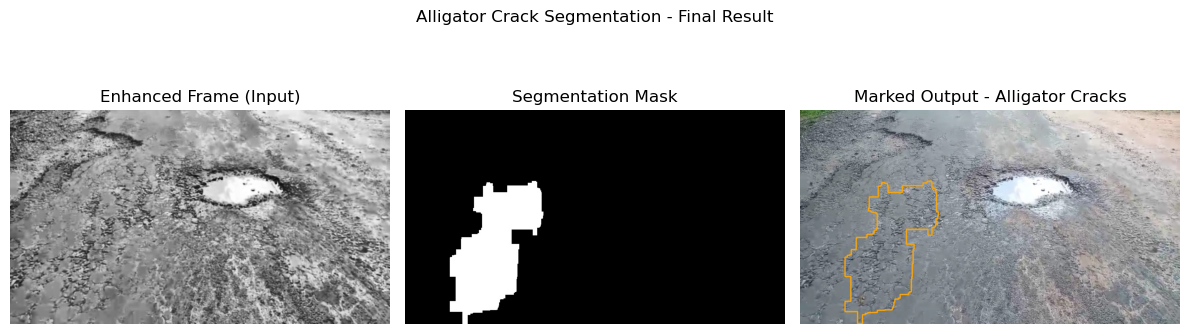

Report example saved: Member3_Segmentation/report_example.jpg

===== Member 3 Segmentation Complete (Final Version) =====
Check the folder: Member3_Segmentation/
Files saved:
  mask_*.jpg               - Binary segmentation masks
  marked_*.jpg             - Frames with alligator crack area in orange
  comparison_*.jpg         - Side by side: Enhanced | Mask | Marked
  test_steps_*.jpg         - Step by step stages
  report_example.jpg       - Clean 3-panel image for the report
  alligator_metrics.txt    - Accuracy, Precision, Recall, F1, IoU, Dice

NOTE: If region not solid enough: increase CLOSING_KERNEL_SIZE (try 41 or 51)
NOTE: If region too large:        decrease CLOSING_KERNEL_SIZE (try 21)
NOTE: If too much noise:          decrease THRESHOLD_VALUE (try 90 or 80)


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# APPROACH:
#   Uses a polygon-shaped ROI to limit processing to only
#   the alligator crack region in each frame group.
#
#   Frames 72-79: cracks in lower-left area
#   Frame  90:    large crack area, same polygon as v4
#   Frames 91-96: diagonal ROI boundary follows the line
#                 between edge crack (top-left) and
#                 alligator crack (lower area)
#                 ROI starts at (0,290) going diagonally
#                 to (330,200) then covers the full lower area
#
#   Inside the ROI:
#   - Fixed threshold detects dark crack texture pixels
#   - Large closing kernel (31x31) merges all detected pixels
#     into one solid region covering the full cracked area
#   - One contour drawn around the full solid region


# ============================================================
# Step 1: Set Up Folders
# ============================================================

input_folder  = "Final_Enhanced/"
gt_folder     = "GroundTruth_AlligatorCracks/"
output_folder = "Member3_Segmentation/"

os.makedirs(output_folder, exist_ok=True)

# ============================================================
# Step 2: Read Alligator Crack Frame Names
# ============================================================

alligator_input = "Frames_AlligatorCracks/"

all_files = os.listdir(alligator_input)

frame_files = []
for f in all_files:
    if f.endswith(".jpg"):
        frame_files.append(f)

frame_files.sort(key=lambda x: int(x.split("_")[1].split(".")[0]))

print("Total alligator crack frames found:", len(frame_files))

# ============================================================
# Step 3: Check Ground Truth Masks
# ============================================================

frames_with_gt = []
for f in frame_files:
    if os.path.exists(gt_folder + f):
        frames_with_gt.append(f)

print("Frames with ground truth masks:", len(frames_with_gt))

if len(frames_with_gt) == 0:
    print("WARNING: No ground truth masks found in", gt_folder)


# ============================================================
# Step 4: Settings
# ============================================================

# Pixels DARKER than this inside ROI = alligator crack texture
THRESHOLD_VALUE = 110

# Large closing kernel to merge all crack pixels into one solid region
CLOSING_KERNEL_SIZE = 31

# Minimum area for the final detected solid region
MIN_AREA = 5000


# ============================================================
# Step 5: Per-frame ROI polygon
# ============================================================

def get_roi_polygon(frame_name, h, w):
    num = int(frame_name.split("_")[1].split(".")[0])

    if num >= 72 and num <= 79:
        # Frames 72-79: crack area in lower-left
        return np.array([
            (160, 160), (300, 160), (310, 230),
            (280, 340), (240, 420), (160, 478),
            (100, 478), (100, 320), (150, 220), (160, 160)
        ], np.int32)

    elif num == 90:
        # Frame 90: larger crack area, left boundary at x=160
        return np.array([
            (160, 145), (460, 145), (470, 230),
            (450, 340), (390, 430), (180, 478),
            (120, 478), (120, 310), (150, 210), (160, 145)
        ], np.int32)

    else:
        # Frames 91-96:
        # Diagonal ROI boundary that follows the line between
        # edge crack (top-left) and alligator crack (lower area)
        # Starts at left edge y=290, goes diagonally to (330,200)
        # This excludes the big edge crack on the left side
        return np.array([
            (0, 290),
            (330, 200),
            (460, 200),
            (470, 270),
            (450, 370),
            (390, 450),
            (200, 478),
            (0, 478),
            (0, 290)
        ], np.int32)


# ============================================================
# Step 6: Segmentation Function
# ============================================================

def segment_alligator_frame(img, frame_name):

    h, w = img.shape[:2]
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Create polygon ROI mask
    roi_polygon = get_roi_polygon(frame_name, h, w)
    roi_mask = np.zeros((h, w), dtype=np.uint8)
    cv2.fillPoly(roi_mask, [roi_polygon], 255)

    # Apply ROI to grayscale
    gray_roi = cv2.bitwise_and(gray, gray, mask=roi_mask)

    # Detect DARK regions inside ROI (cracked road surface is dark)
    _, binary = cv2.threshold(gray_roi, THRESHOLD_VALUE, 255, cv2.THRESH_BINARY_INV)
    binary = cv2.bitwise_and(binary, binary, mask=roi_mask)

    # Large closing - merge all crack pixels into one solid region
    kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT,
                   (CLOSING_KERNEL_SIZE, CLOSING_KERNEL_SIZE))
    closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel_close)

    # Opening - remove small noise outside the main region
    kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (7, 7))
    cleaned = cv2.morphologyEx(closed, cv2.MORPH_OPEN, kernel_open)

    # Re-apply ROI to keep within polygon boundary
    final_mask = cv2.bitwise_and(cleaned, cleaned, mask=roi_mask)

    return final_mask, gray, binary, roi_polygon


# ============================================================
# Step 7: Test on First Frame
# ============================================================

print("\nTesting on first frame...")

test_name = frame_files[0]
test_img  = cv2.imread(alligator_input + test_name)

if test_img is None:
    print("Could not read the first frame. Check the folder path.")
else:

    final_mask, gray, binary, roi_poly = segment_alligator_frame(test_img, test_name)

    contours, _ = cv2.findContours(final_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    good_contours = [c for c in contours if cv2.contourArea(c) > MIN_AREA]

    marked_test = test_img.copy()
    cv2.drawContours(marked_test, good_contours, -1, (0, 165, 255), 2)
    cv2.polylines(marked_test, [roi_poly], True, (0, 255, 255), 1)

    plt.figure(figsize=(18, 3))

    plt.subplot(1, 5, 1)
    plt.imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
    plt.title("Original Frame")
    plt.axis('off')

    plt.subplot(1, 5, 2)
    plt.imshow(gray, cmap='gray')
    plt.title("Grayscale")
    plt.axis('off')

    plt.subplot(1, 5, 3)
    plt.imshow(binary, cmap='gray')
    plt.title("Dark Regions\ninside ROI")
    plt.axis('off')

    plt.subplot(1, 5, 4)
    plt.imshow(final_mask, cmap='gray')
    plt.title("After Large Closing\n(Solid Region)")
    plt.axis('off')

    plt.subplot(1, 5, 5)
    plt.imshow(cv2.cvtColor(marked_test, cv2.COLOR_BGR2RGB))
    plt.title("Marked Output\n(yellow=ROI)")
    plt.axis('off')

    plt.suptitle("Alligator Crack Segmentation Final (" + test_name + ")")
    plt.tight_layout()
    plt.savefig(output_folder + "test_steps_" + test_name)
    plt.show()

    print("Test done. Check:", output_folder + "test_steps_" + test_name)
    print("Solid regions found:", len(good_contours))
    print()
    print("If region not solid enough: increase CLOSING_KERNEL_SIZE (try 41 or 51)")
    print("If region too large: decrease CLOSING_KERNEL_SIZE (try 21)")
    print("If too much noise: decrease THRESHOLD_VALUE (try 90 or 80)")


# ============================================================
# Step 8: Process All Frames
# ============================================================

print("\nProcessing all alligator crack frames...")

for frame_name in frame_files:

    img = cv2.imread(alligator_input + frame_name)

    if img is None:
        print("Could not read:", frame_name, "- Skipping.")
        continue

    final_mask, gray, binary, roi_poly = segment_alligator_frame(img, frame_name)

    contours, _ = cv2.findContours(final_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    good_contours = [c for c in contours if cv2.contourArea(c) > MIN_AREA]

    marked = img.copy()
    cv2.drawContours(marked, good_contours, -1, (0, 165, 255), 2)

    cv2.imwrite(output_folder + "mask_"       + frame_name, final_mask)
    cv2.imwrite(output_folder + "marked_"     + frame_name, marked)

    enhanced_bgr = cv2.imread(input_folder + frame_name)
    if enhanced_bgr is None:
        enhanced_bgr = img

    mask_bgr   = cv2.cvtColor(final_mask, cv2.COLOR_GRAY2BGR)
    comparison = np.hstack((enhanced_bgr, mask_bgr, marked))
    cv2.imwrite(output_folder + "comparison_" + frame_name, comparison)

print("Done. All outputs saved in:", output_folder)


# ============================================================
# Step 9: Calculate Evaluation Metrics
# ============================================================

print("\n--- Evaluation Metrics (Frames with Ground Truth) ---")
print("Frame                  Accuracy  Precision  Recall    F1        IoU       Dice")
print("-" * 90)

results = []

for frame_name in frames_with_gt:

    img    = cv2.imread(alligator_input + frame_name)
    gt_img = cv2.imread(gt_folder + frame_name, cv2.IMREAD_GRAYSCALE)

    if img is None or gt_img is None:
        print("Could not read:", frame_name, "- Skipping.")
        continue

    final_mask, _, _, _ = segment_alligator_frame(img, frame_name)

    gt_img = cv2.resize(gt_img, (final_mask.shape[1], final_mask.shape[0]))

    _, gt_bin   = cv2.threshold(gt_img,     127, 1, cv2.THRESH_BINARY)
    _, pred_bin = cv2.threshold(final_mask, 127, 1, cv2.THRESH_BINARY)

    TP = int(np.sum((pred_bin == 1) & (gt_bin == 1)))
    FP = int(np.sum((pred_bin == 1) & (gt_bin == 0)))
    FN = int(np.sum((pred_bin == 0) & (gt_bin == 1)))
    TN = int(np.sum((pred_bin == 0) & (gt_bin == 0)))

    total = TP + FP + FN + TN

    accuracy  = (TP + TN) / total
    precision = TP / (TP + FP)        if (TP + FP) > 0 else 0.0
    recall    = TP / (TP + FN)        if (TP + FN) > 0 else 0.0
    f1        = 2*precision*recall / (precision+recall) if (precision+recall) > 0 else 0.0
    iou       = TP / (TP + FP + FN)   if (TP + FP + FN) > 0 else 0.0
    dice      = (2*TP) / (2*TP+FP+FN) if (2*TP+FP+FN) > 0 else 0.0

    results.append([frame_name, accuracy, precision, recall, f1, iou, dice])

    print(frame_name, "\t",
          round(accuracy, 4), "\t", round(precision, 4), "\t",
          round(recall,   4), "\t", round(f1,        4), "\t",
          round(iou,      4), "\t", round(dice,      4))


# ============================================================
# Step 10: Averages and Save Metrics
# ============================================================

if len(results) > 0:

    avg_acc = sum(r[1] for r in results) / len(results)
    avg_pre = sum(r[2] for r in results) / len(results)
    avg_rec = sum(r[3] for r in results) / len(results)
    avg_f1  = sum(r[4] for r in results) / len(results)
    avg_iou = sum(r[5] for r in results) / len(results)
    avg_dic = sum(r[6] for r in results) / len(results)

    print("-" * 90)
    print("AVERAGE", "\t\t\t",
          round(avg_acc, 4), "\t", round(avg_pre, 4), "\t",
          round(avg_rec, 4), "\t", round(avg_f1,  4), "\t",
          round(avg_iou, 4), "\t", round(avg_dic, 4))

    result_file = open(output_folder + "alligator_metrics.txt", "w")
    result_file.write("Alligator Crack Segmentation - Evaluation Results (Final Version)\n")
    result_file.write("Member 3 - ICT2403 Graphics and Image Processing\n")
    result_file.write("Degradation Type: Alligator Crack\n")
    result_file.write("Approach: Polygon ROI + Dark region detection + Large closing\n")
    result_file.write("Threshold Value: " + str(THRESHOLD_VALUE) + "\n")
    result_file.write("Closing Kernel Size: " + str(CLOSING_KERNEL_SIZE) + "\n")
    result_file.write("Min Contour Area: " + str(MIN_AREA) + "\n")
    result_file.write("ROI Frames 72-79: lower-left polygon\n")
    result_file.write("ROI Frame  90:    large lower-left polygon\n")
    result_file.write("ROI Frames 91-96: diagonal boundary polygon (excludes edge crack)\n")
    result_file.write("Total frames tested: " + str(len(frame_files)) + "\n")
    result_file.write("Frames with ground truth: " + str(len(results)) + "\n")
    result_file.write("-" * 90 + "\n")
    result_file.write("Frame                  Accuracy  Precision  Recall    F1        IoU       Dice\n")
    result_file.write("-" * 90 + "\n")

    for r in results:
        result_file.write(r[0] + "\t" +
                          str(round(r[1], 4)) + "\t" + str(round(r[2], 4)) + "\t" +
                          str(round(r[3], 4)) + "\t" + str(round(r[4], 4)) + "\t" +
                          str(round(r[5], 4)) + "\t" + str(round(r[6], 4)) + "\n")

    result_file.write("-" * 90 + "\n")
    result_file.write("AVERAGE\t\t\t" +
                      str(round(avg_acc, 4)) + "\t" + str(round(avg_pre, 4)) + "\t" +
                      str(round(avg_rec, 4)) + "\t" + str(round(avg_f1,  4)) + "\t" +
                      str(round(avg_iou, 4)) + "\t" + str(round(avg_dic, 4)) + "\n")
    result_file.close()

    print("\nMetrics saved to:", output_folder + "alligator_metrics.txt")

else:
    print("\nNo ground truth masks found. Add masks to:", gt_folder)


# ============================================================
# Step 11: Save Report Example Image
# ============================================================

example_name = frame_files[0]
img_enhanced = cv2.imread(input_folder + example_name)
img_marked   = cv2.imread(output_folder + "marked_" + example_name)
img_mask     = cv2.imread(output_folder + "mask_"   + example_name, cv2.IMREAD_GRAYSCALE)

if img_enhanced is None:
    img_enhanced = cv2.imread(alligator_input + example_name)

if img_enhanced is not None and img_marked is not None and img_mask is not None:

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(img_enhanced, cv2.COLOR_BGR2RGB))
    plt.title("Enhanced Frame (Input)")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(img_mask, cmap='gray')
    plt.title("Segmentation Mask")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(img_marked, cv2.COLOR_BGR2RGB))
    plt.title("Marked Output - Alligator Cracks")
    plt.axis('off')

    plt.suptitle("Alligator Crack Segmentation - Final Result")
    plt.tight_layout()
    plt.savefig(output_folder + "report_example.jpg")
    plt.show()

    print("Report example saved:", output_folder + "report_example.jpg")
